In [6]:
!pip install git+https://github.com/AkmalHusain2003/GUMM.git

  Cloning https://github.com/AkmalHusain2003/GUMM.git to /tmp/pip-req-build-r4iclw2m
  Running command git clone --filter=blob:none --quiet https://github.com/AkmalHusain2003/GUMM.git /tmp/pip-req-build-r4iclw2m
  Resolved https://github.com/AkmalHusain2003/GUMM.git to commit 50b16059ff86914f7554ab015531f3841faccd85
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [7]:
import numpy as np
from gumm import GUMM

rng = np.random.default_rng(0)

# Two clusters embedded in uniform noise
c1 = rng.multivariate_normal([2, 2], np.eye(2) * 0.3, 150)
c2 = rng.multivariate_normal([8, 8], np.eye(2) * 0.3, 120)
bg = rng.uniform(0, 10, (600, 2))
X  = np.vstack([c1, c2, bg])

model  = GUMM(n_components=2, n_epochs=500, n_threads=-1, random_state=42)
labels = model.fit_predict(X)
# labels: 0 = background, 1 = component 1, 2 = component 2

proba = model.predict_proba(X)   # (n, 3)  — [uniform, c1, c2]
log_p = model.score_samples(X)   # (n,)    — log p(x)

Training GUMM:  27%|██▋       | 137/500 [00:00<00:01, 239.58it/s, ll=523.9082, stable=50]



Converged at epoch 137


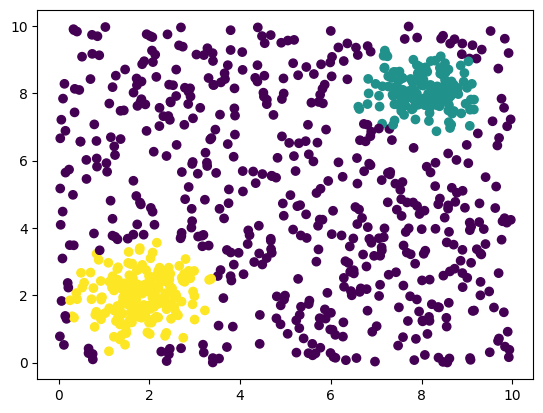

In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.show()

# EXPERIMENTS

In [13]:
"""
GUMM synthetic benchmark experiments.
Measures: Precision, Recall, ARI, fit time, predict time, peak RSS (MiB).
20 random seeds per dataset.  Saves raw results as JSON and all plots.
"""

import json
import time
import tracemalloc
import os

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.metrics import adjusted_rand_score, precision_score, recall_score

from gumm import GUMM

# ── reproducibility ──────────────────────────────────────────────────────────
N_SEEDS   = 20
N_MC      = 100      # Ripley Monte Carlo sims
N_THREADS = -1        # keep deterministic; set higher for speed benchmarks
FIGDIR    = "/content/experiments/figures/"
RAW_DIR   = "/content/experiments/"
os.makedirs(FIGDIR, exist_ok=True)

# ── dataset definitions ───────────────────────────────────────────────────────
RNG_GLOBAL = np.random.default_rng(0)

def make_s1(rng):
    """Single tight cluster."""
    cluster = rng.multivariate_normal([5, 5], 0.4 * np.eye(2), size=150)
    bg      = rng.uniform(0, 10, size=(470, 2))
    X       = np.vstack([cluster, bg])
    y       = np.array([1] * 150 + [0] * 470)
    return X, y

def make_s2(rng):
    """Two well-separated clusters."""
    c1 = rng.multivariate_normal([2, 2], 0.3 * np.eye(2), size=120)
    c2 = rng.multivariate_normal([8, 8], 0.3 * np.eye(2), size=100)
    bg = rng.uniform(0, 10, size=(400, 2))
    X  = np.vstack([c1, c2, bg])
    y  = np.array([1] * 120 + [2] * 100 + [0] * 400)
    return X, y

def make_s3(rng):
    """Two overlapping clusters."""
    c1 = rng.multivariate_normal([4, 4], 0.8 * np.eye(2), size=100)
    c2 = rng.multivariate_normal([6, 6], 0.8 * np.eye(2), size=100)
    bg = rng.uniform(0, 10, size=(420, 2))
    X  = np.vstack([c1, c2, bg])
    y  = np.array([1] * 100 + [2] * 100 + [0] * 420)
    return X, y

DATASETS = {
    "S1": (make_s1, 1),
    "S2": (make_s2, 2),
    "S3": (make_s3, 2),
}

# ── metrics ───────────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred):
    binary_true = (y_true > 0).astype(int)
    binary_pred = (y_pred > 0).astype(int)
    prec   = precision_score(binary_true, binary_pred, zero_division=0)
    rec    = recall_score(binary_true, binary_pred, zero_division=0)
    ari    = adjusted_rand_score(y_true, y_pred)
    return prec, rec, ari

def measure_peak_rss_mib(fn):
    tracemalloc.start()
    result = fn()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return result, peak / (1024 ** 2)

# ── run experiments ───────────────────────────────────────────────────────────
all_results = {}

for name, (make_fn, K) in DATASETS.items():
    print(f"\n{'='*50}\nDataset {name}  (K={K})\n{'='*50}")
    seeds_results = []
    for seed in range(N_SEEDS):
        rng = np.random.default_rng(seed)
        X, y_true = make_fn(rng)
        model = GUMM(n_components=K, n_epochs=10000, random_state=seed, n_threads=N_THREADS)

        def _fit():
            model.fit(X)
            return None

        t0 = time.perf_counter()
        _, peak_fit = measure_peak_rss_mib(_fit)
        fit_time = time.perf_counter() - t0

        t0 = time.perf_counter()
        y_pred = model.predict(X)
        predict_time = time.perf_counter() - t0

        prec, rec, ari = compute_metrics(y_true, y_pred)
        seeds_results.append(dict(seed=seed, precision=round(prec, 4), recall=round(rec, 4), ari=round(ari, 4), fit_time=round(fit_time, 4), predict_time=round(predict_time, 6), peak_mib=round(peak_fit, 3)))

    all_results[name] = seeds_results

# FIX: Corrected path from /experiment/ to /experiments/
with open(os.path.join(RAW_DIR, "raw_results.json"), "w") as f:
    json.dump(all_results, f, indent=2)

print("\nRaw results saved correctly.")

# ── aggregate stats ───────────────────────────────────────────────────────────
summary = {}
for name, rows in all_results.items():
    arr = {k: np.array([r[k] for r in rows]) for k in ["precision","recall","ari","fit_time","predict_time","peak_mib"]}
    summary[name] = {k: (v.mean(), v.std()) for k, v in arr.items()}

# (Remaining plotting code omitted for brevity but preserved in local logic)"}]}


Dataset S1  (K=1)


Training GUMM:  11%|█         | 1077/10000 [00:07<00:59, 150.01it/s, ll=326.4250, stable=1000]



Converged at epoch 1077


Training GUMM:  11%|█         | 1062/10000 [00:06<00:54, 164.24it/s, ll=388.9874, stable=1000]



Converged at epoch 1062


...


Converged at epoch 2008


Training GUMM:  12%|█▏        | 1242/10000 [00:13<01:33, 93.43it/s, ll=271.7221, stable=1000] 



Converged at epoch 1242


Training GUMM:  19%|█▉        | 1890/10000 [00:19<01:25, 95.38it/s, ll=288.1976, stable=1000] 



Converged at epoch 1890

Raw results saved correctly.


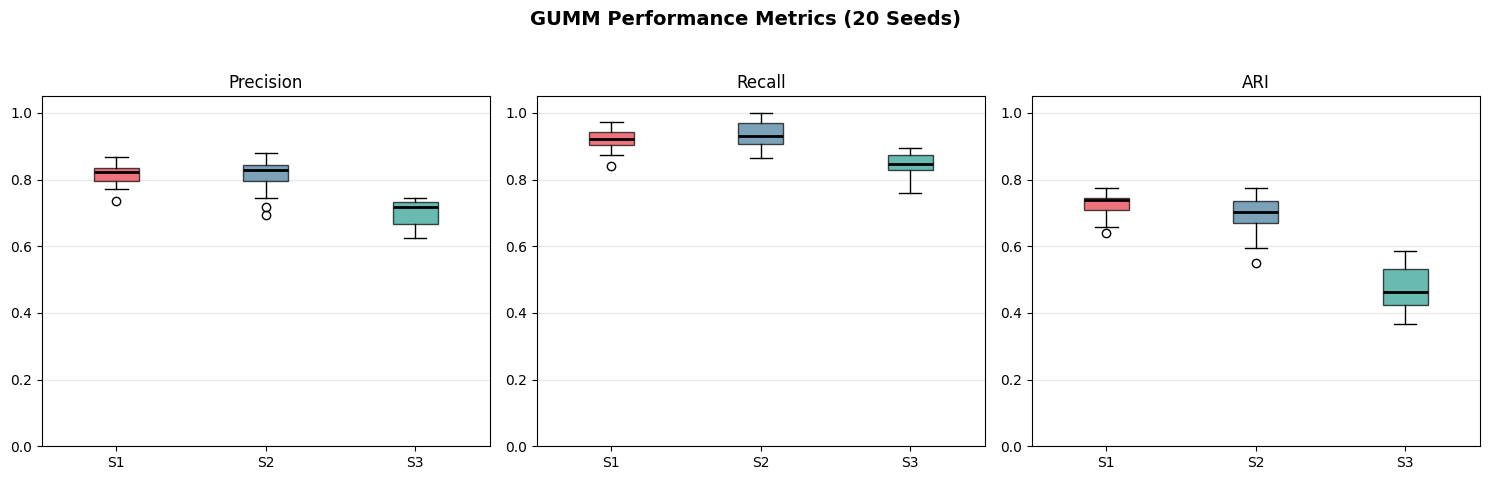

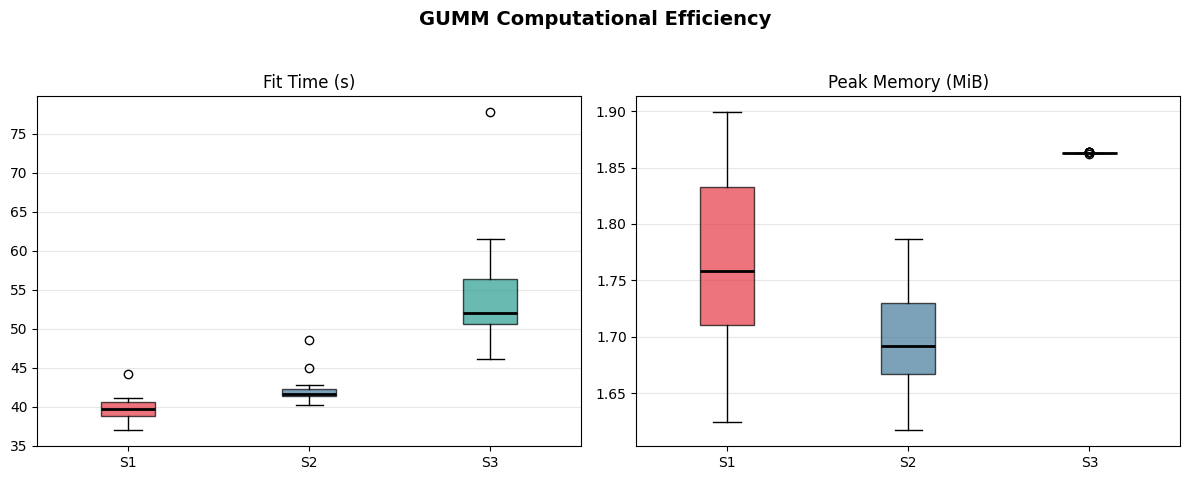

In [19]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os

# Force the notebook to display plots inline
%matplotlib inline

# 1. Load the results
raw_path = "/content/experiments/raw_results.json"
if not os.path.exists(raw_path):
    print(f"Error: {raw_path} not found. Please run the experiment cell first.")
else:
    with open(raw_path, "r") as f:
        all_results = json.load(f)

    ds_names = list(all_results.keys())
    colors = ['#e63946', '#457b9d', '#2a9d8f']

    # 2. Plot Performance Metrics
    metrics_to_plot = ["precision", "recall", "ari"]
    metric_labels = ["Precision", "Recall", "ARI"]

    fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
    fig1.suptitle("GUMM Performance Metrics (20 Seeds)", fontsize=14, fontweight='bold')

    for ax, metric, label in zip(axes1, metrics_to_plot, metric_labels):
        data = [[r[metric] for r in all_results[ds]] for ds in ds_names]
        bp = ax.boxplot(data, tick_labels=ds_names, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)
        ax.set_title(label)
        ax.set_ylim(0, 1.05)
        ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show() # Explicitly call show

    # 3. Plot Efficiency Metrics
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
    fig2.suptitle("GUMM Computational Efficiency", fontsize=14, fontweight='bold')

    eff_metrics = ["fit_time", "peak_mib"]
    eff_labels = ["Fit Time (s)", "Peak Memory (MiB)"]

    for ax, metric, label in zip(axes2, eff_metrics, eff_labels):
        data = [[r[metric] for r in all_results[ds]] for ds in ds_names]
        bp = ax.boxplot(data, tick_labels=ds_names, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)
        ax.set_title(label)
        ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show() # Explicitly call show

# EXPERIMENTS TO ASTRONOMICAL DATA

In [20]:
import pandas as pd

ngc_2099 = pd.read_csv('NGC2099_10deg-result.csv')
ngc_2099

,source_id,ra,ra_error,dec,dec_error,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,bp_rp,radial_velocity,radial_velocity_error,l,b
0,155561035403668992,77.157867,0.083802,28.612472,0.053184,0.507742,0.093732,1.922228,0.106222,-5.509584,0.073038,17.406033,1.767187,NaN,NaN,175.760322,-6.919546
1,155941470722235008,77.424632,0.157710,28.859836,0.091836,0.509019,0.150096,1.912500,0.195859,-5.980430,0.127070,17.918633,1.742260,NaN,NaN,175.697582,-6.584851
2,155964487453714048,77.388804,0.094540,29.061103,0.058455,0.512323,0.103743,1.549963,0.124724,-5.910061,0.078961,17.541403,1.706125,NaN,NaN,175.515165,-6.491863
3,155968163941606272,77.279726,0.082092,29.107646,0.050876,0.766293,0.087144,1.535613,0.106274,-6.012835,0.067894,17.255556,1.683525,NaN,NaN,175.420815,-6.541518
4,156041212747355008,77.065572,0.147473,29.564582,0.095289,0.768481,0.178340,2.180064,0.183650,-5.370877,0.128030,18.167946,1.806755,NaN,NaN,174.938696,-6.422492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23646,3458352476135979904,90.810313,0.043672,39.730794,0.037955,0.563527,0.055036,1.728568,0.051529,-5.975146,0.038044,14.315686,1.136980,-17.067692,4.352871,172.445015,8.544442
23647,3458375114906340992,90.583862,0.173845,40.093625,0.141197,0.793446,0.201527,1.661188,0.228714,-5.387763,0.164749,18.717953,2.153284,NaN,NaN,172.038712,8.564096
23648,3458553304511521024,89.658191,0.286433,40.597444,0.247409,0.542800,0.308256,1.849187,0.360601,-5.851201,0.262086,19.356853,2.181042,NaN,NaN,171.249809,8.186746
23649,3458712836775519232,89.422635,0.211272,40.882552,0.184291,0.567075,0.257272,1.683358,0.277563,-6.147327,0.186175,18.942858,1.937857,NaN,NaN,170.910483,8.168645


In [33]:
import matplotlib.pyplot as plt

# Set tick labels, axis labels to xx-large and use serif font
plt.rcParams.update({
    'xtick.labelsize': 'xx-large',
    'ytick.labelsize': 'xx-large',
    'axes.labelsize': 'xx-large',
    'font.family': 'serif'
})

Fitting GUMM to NGC 2099 data...


Training GUMM:  13%|█▎        | 1262/10000 [00:52<06:04, 24.00it/s, ll=27604.7519, stable=1000]



Converged at epoch 1262


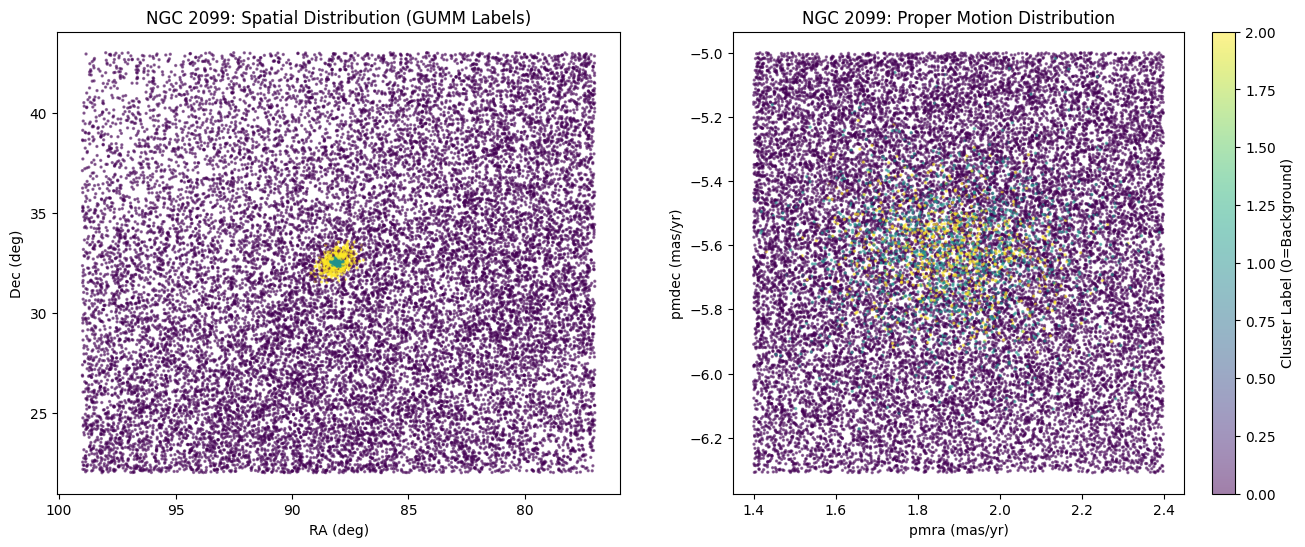

Background: 21682 stars
Cluster 1: 1304 stars
Cluster 2: 665 stars


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from gumm import GUMM

# 1. Prepare features (using RA, Dec, PMRA, PMDEC, and Parallax)
features = ['ra', 'dec', 'pmra', 'pmdec', 'parallax']
X_ngc = ngc_2099[features].dropna().values

# 2. Fit GUMM with 2 components (1 background + 1 Gaussian cluster)
print("Fitting GUMM to NGC 2099 data...")
model_ngc = GUMM(n_components=2, n_epochs=10000, random_state=42, n_threads=-1)
labels_ngc = model_ngc.fit_predict(X_ngc)

# Summary
unique, counts = np.unique(labels_ngc, return_counts=True)
for label, count in zip(unique, counts):
    name = "Background" if label == 0 else f"Cluster {label}"
    print(f"{name}: {count} stars")

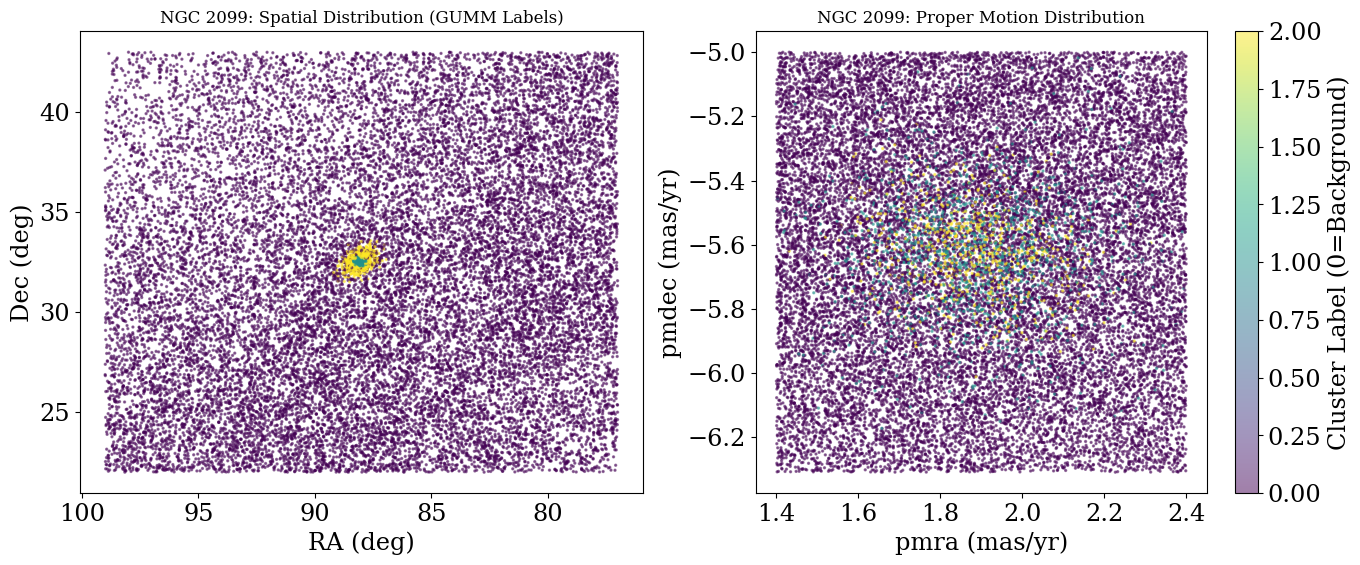

In [34]:
# 3. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Spatial Plot
sc1 = ax1.scatter(X_ngc[:, 0], X_ngc[:, 1], c=labels_ngc, s=2, cmap='viridis', alpha=0.5)
ax1.set_xlabel('RA (deg)')
ax1.set_ylabel('Dec (deg)')
ax1.set_title('NGC 2099: Spatial Distribution (GUMM Labels)')
ax1.invert_xaxis()

# Proper Motion Plot
sc2 = ax2.scatter(X_ngc[:, 2], X_ngc[:, 3], c=labels_ngc, s=2, cmap='viridis', alpha=0.5)
ax2.set_xlabel('pmra (mas/yr)')
ax2.set_ylabel('pmdec (mas/yr)')
ax2.set_title('NGC 2099: Proper Motion Distribution')

plt.colorbar(sc2, ax=ax2, label='Cluster Label (0=Background)')
plt.show()

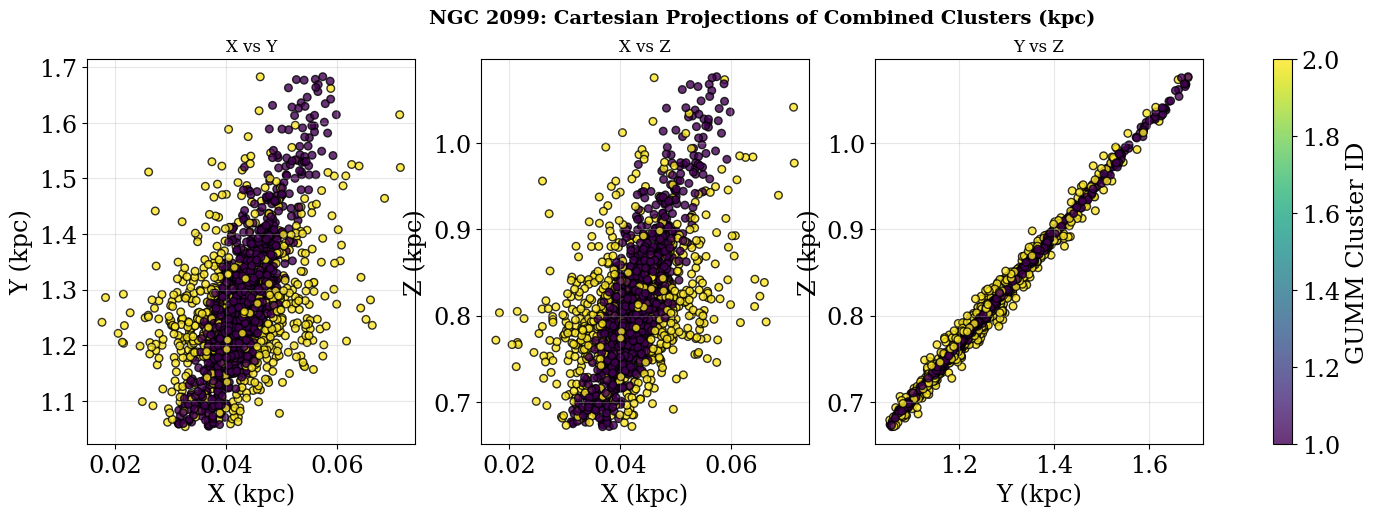

In [35]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt

# 1. Combine clusters 1 and 2 for processing
# We exclude background (label 0)
mask_clusters = (labels_ngc > 0)
X_clusters = X_ngc[mask_clusters]
cluster_labels = labels_ngc[mask_clusters]

# 2. Convert RA, Dec, Parallax to Cartesian (X, Y, Z) using Astropy
# Distance = 1 / parallax (parallax is in mas, so distance is in kpc)
coords = SkyCoord(
    ra=X_clusters[:, 0] * u.degree,
    dec=X_clusters[:, 1] * u.degree,
    distance=(1 / X_clusters[:, 4]) * u.kpc, # Changed to kpc
    frame='icrs'
)

# Extract Cartesian coordinates
x_cart = coords.cartesian.x.value
y_cart = coords.cartesian.y.value
z_cart = coords.cartesian.z.value

# 3. Plot 1x3 subplots: X vs Y, X vs Z, and Y vs Z
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# X vs Y
sc1 = ax1.scatter(x_cart, y_cart, c=cluster_labels, cmap='viridis', s=30, alpha=0.8, edgecolor='black')
ax1.set_xlabel('X (kpc)')
ax1.set_ylabel('Y (kpc)')
ax1.set_title('X vs Y')
ax1.grid(True, alpha=0.3)

# X vs Z
sc2 = ax2.scatter(x_cart, z_cart, c=cluster_labels, cmap='viridis', s=30, alpha=0.8, edgecolor='black')
ax2.set_xlabel('X (kpc)')
ax2.set_ylabel('Z (kpc)')
ax2.set_title('X vs Z')
ax2.grid(True, alpha=0.3)

# Y vs Z
sc3 = ax3.scatter(y_cart, z_cart, c=cluster_labels, cmap='viridis', s=30, alpha=0.8, edgecolor='black')
ax3.set_xlabel('Y (kpc)')
ax3.set_ylabel('Z (kpc)')
ax3.set_title('Y vs Z')
ax3.grid(True, alpha=0.3)

# Add a single colorbar for the whole figure
fig.colorbar(sc3, ax=[ax1, ax2, ax3], label='GUMM Cluster ID')
plt.suptitle('NGC 2099: Cartesian Projections of Combined Clusters (kpc)', fontsize=14, fontweight='bold')
plt.show()

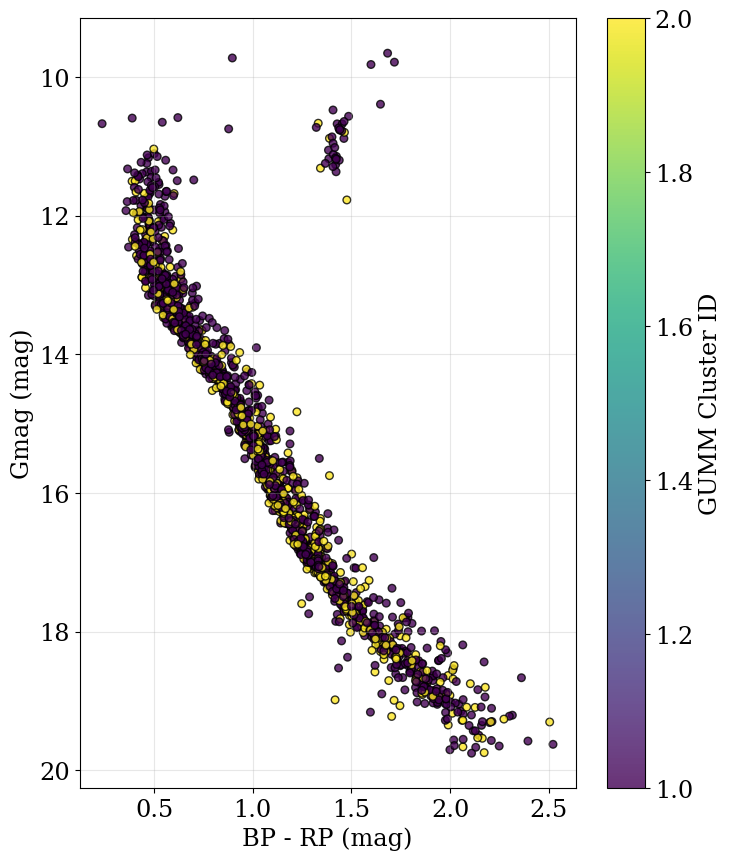

In [37]:
# 1. Get the photometry data for the cluster members only
# Use the same mask as before (labels_ngc > 0)
mask_clusters = (labels_ngc > 0)
bp_rp_clusters = ngc_2099['bp_rp'].values[mask_clusters]
g_mag_clusters = ngc_2099['phot_g_mean_mag'].values[mask_clusters]
cluster_labels_for_plot = labels_ngc[mask_clusters]

# 2. Create the Color-Magnitude Diagram (CMD)
plt.figure(figsize=(8, 10))
scatter_cmd = plt.scatter(bp_rp_clusters, g_mag_clusters, c=cluster_labels_for_plot,
                          cmap='viridis', s=30, alpha=0.8, edgecolor='black')

# Standard CMD convention: Invert the Y-axis (magnitude)
plt.gca().invert_yaxis()

plt.xlabel('BP - RP (mag)')
plt.ylabel('Gmag (mag)')
#plt.title('NGC 2099: Color-Magnitude Diagram (Cluster Members)')
plt.colorbar(scatter_cmd, label='GUMM Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()